In [117]:
import sys, os, re, jax
sys.path.append(os.path.abspath("./../../feedback-grape"))
sys.path.append(os.path.abspath("./../../"))
sys.path.append(os.path.abspath("./../"))

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from plot_helpers import (
    open_from_dir,
    plot_runs,
    plot_runs_1D,
    plot_grid,
    grid_grouped_params,
    select_best_runs,
    extract_time_constants,
    sort_by,
    _labels_from_params,
)

In [118]:
dir_ = "./01_results"
#favour_oscillations = lambda fidelities: np.mean([np.max(fidelities[i:i+4]) for i in range(0, len(fidelities), 4)])
fidelities_mat, params_grouped, params_each = open_from_dir(dir_ + "/eval")#, exclude=r".*(_s=1)|(_s=2).*")
fidelities_best_mat, params_grouped_best, params_each_best = select_best_runs(fidelities_mat, params_each)#, objective_fun=favour_oscillations)
print(params_grouped_best)
fidelities_mat_stab, params_grouped_stab, params_each_stab = open_from_dir(dir_ + "/custom/Stabilizer code")
fidelities_mat_stab, params_grouped_stab, params_each_stab = sort_by(fidelities_mat_stab, params_each_stab, params_each_best, ignored_keys=["s", "l", "rhoe", "Nmeas"], do_remove_missing=True) # to have same order as before. Ignore params not needed for stabilizer code. Also ignore "rhoe" because of earlier bug in saving/loading.

Opening files...


 33%|███▎      | 191/576 [00:00<00:00, 1903.99it/s]

Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.0006579332246575682_rhot=bloch_rhoe=bloch_s=1.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0006579332246575682_gammam=0.0012328467394420659_rhot=bloch_rhoe=bloch_s=0.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0012328467394420659_gammam=0.0012328467394420659_rhot=bloch_rhoe=bloch_s=0.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.004328761281083057_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=3.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0001_gammam=0.0012328467394420659_rhot=bloch_rhoe=bloch_s=3.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.002310129700083158_gammam=0.05336699231206307_rhot=bloch_rhoe=bloch_s=1.json.
Parameter model not found in filename 

 75%|███████▌  | 432/576 [00:00<00:00, 2198.60it/s]

Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.002310129700083158_gammam=0.0006579332246575682_rhot=bloch_rhoe=bloch_s=1.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.02848035868435799_gammam=0.004328761281083057_rhot=bloch_rhoe=bloch_s=2.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0003511191734215131_gammam=0.1_rhot=bloch_rhoe=bloch_s=2.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.008111308307896872_gammam=0.05336699231206307_rhot=bloch_rhoe=bloch_s=2.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.004328761281083057_gammam=0.01519911082952933_rhot=bloch_rhoe=bloch_s=2.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.1_gammam=0.0001_rhot=bloch_rhoe=bloch_s=0.json.


100%|██████████| 576/576 [00:00<00:00, 2170.01it/s]


Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.1_gammam=0.1_rhot=bloch_rhoe=bloch_s=0.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0012328467394420659_gammam=0.0001_rhot=bloch_rhoe=bloch_s=1.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.1_gammam=0.0012328467394420659_rhot=bloch_rhoe=bloch_s=1.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.01519911082952933_gammam=0.0003511191734215131_rhot=bloch_rhoe=bloch_s=0.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.02848035868435799_gammam=0.01519911082952933_rhot=bloch_rhoe=bloch_s=1.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.1_gammam=0.05336699231206307_rhot=bloch_rhoe=bloch_s=2.json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.1_gammam=0.00811130830789687

100%|██████████| 144/144 [00:00<00:00, 2256.11it/s]

Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.1_gammam=0.0003511191734215131_rhot=bloch_rhoe=bloch_s=2..json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.01519911082952933_gammam=0.0012328467394420659_rhot=bloch_rhoe=bloch_s=3..json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0001_gammam=0.02848035868435799_rhot=bloch_rhoe=bloch_s=1..json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.004328761281083057_gammam=0.008111308307896872_rhot=bloch_rhoe=bloch_s=3..json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0006579332246575682_gammam=0.05336699231206307_rhot=bloch_rhoe=bloch_s=1..json.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0006579332246575682_gammam=0.0003511191734215131_rhot=bloch_rhoe=bloch_s=1..json.
Parameter model not found in filename lut_t=3_l=2_w

Text(0.5, 1.0, 'Fidelity over Time for all runs')

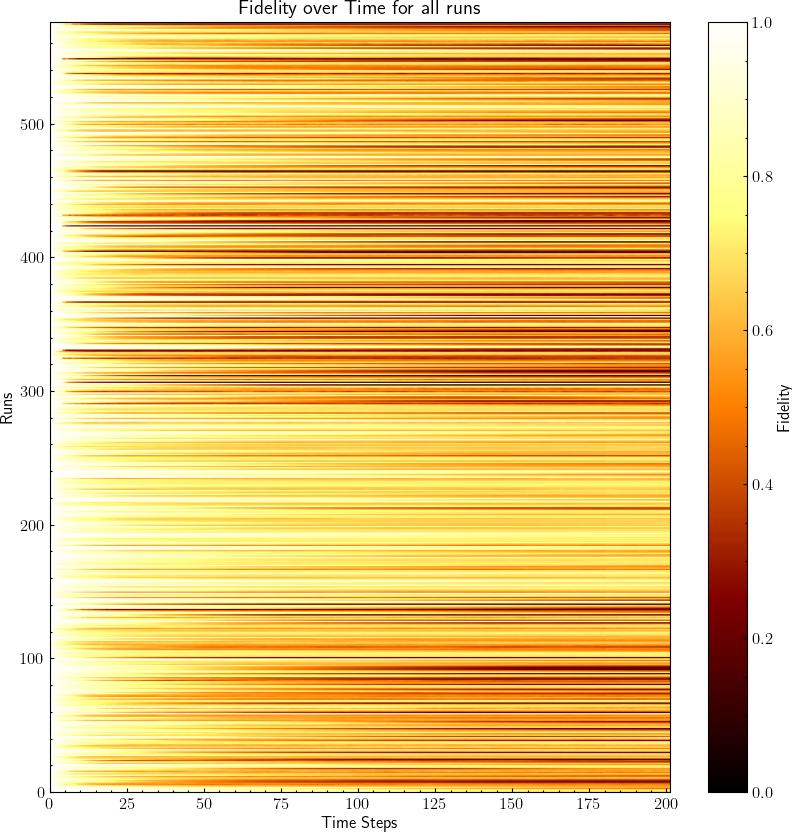

In [119]:
fig, ax, im = plot_runs(
    fidelities_mat,
    params_grouped,
    sort_by="s",
    show_labels=False,
    figsize=(10,10),
)
ax.set_title("Fidelity over Time for all runs")

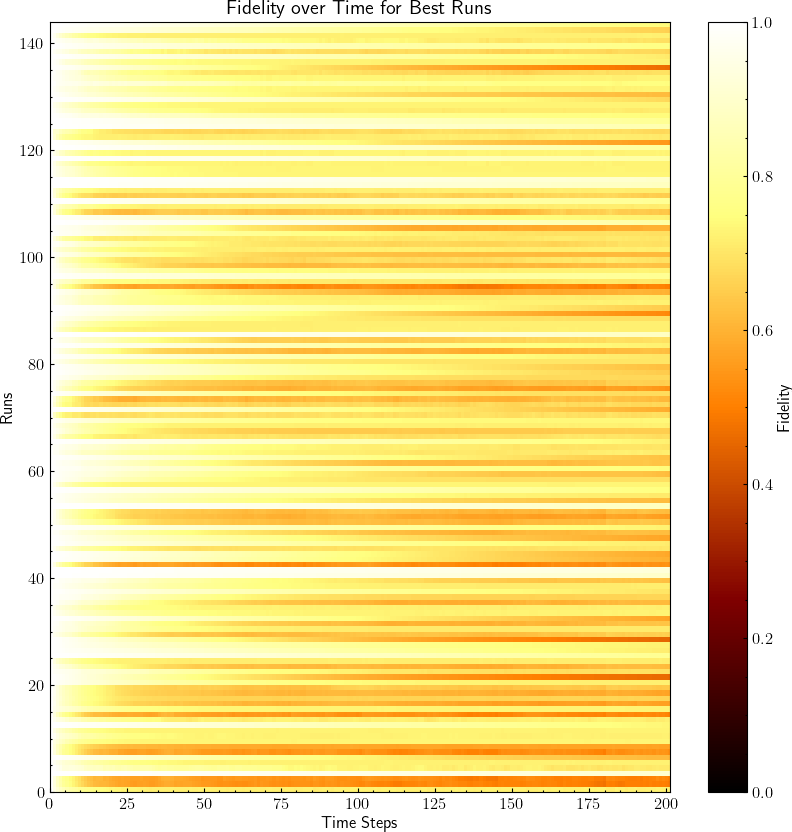

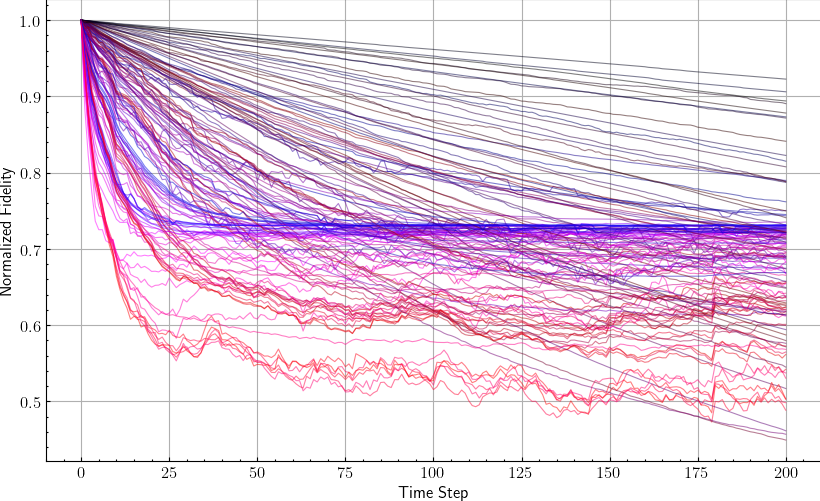

In [120]:
fig, ax, im = plot_runs(
    fidelities_best_mat,
    params_grouped_best,
    sort_by="s",
    show_labels=False,
    figsize=(10,10),
)
ax.set_title("Fidelity over Time for Best Runs")

idx = np.arange(fidelities_best_mat.shape[0]) #np.random.choice(fidelities_best_mat.shape[0], N, replace=False)
fig, ax = plot_runs_1D(
    fidelities_best_mat[idx],
    {param: [params_grouped_best[param][i] for i in idx] for param in params_grouped_best},
    figsize=(10,6),
)

Opening files...


100%|██████████| 145/145 [00:00<00:00, 3079.80it/s]

Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.05336699231206307_gammam=0.002310129700083158_rhot=bloch_rhoe=bloch_s=2..npz.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0001_gammam=0.01519911082952933_rhot=bloch_rhoe=bloch_s=2..npz.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0012328467394420659_gammam=0.02848035868435799_rhot=bloch_rhoe=bloch_s=3..npz.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.0001873817422860383_gammam=0.01519911082952933_rhot=bloch_rhoe=bloch_s=2..npz.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.002310129700083158_gammam=0.004328761281083057_rhot=bloch_rhoe=bloch_s=0..npz.
Parameter model not found in filename lut_t=3_l=2_w=111_Nqubits=3_Nmeas=2_gammap=0.02848035868435799_gammam=0.0006579332246575682_rhot=bloch_rhoe=bloch_s=1..npz.
Parameter model not found in filename lut_t=

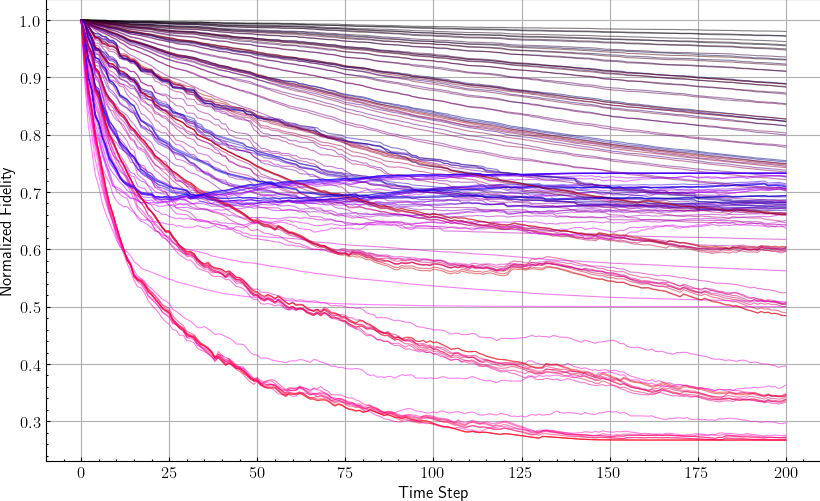

In [121]:
fidelities_mat_base, params_grouped_base, params_each_base = open_from_dir(dir_ + "/baseline")

idx = np.arange(fidelities_mat_stab.shape[0])
fig, ax = plot_runs_1D(
    fidelities_mat_stab[idx],
    {param: [params_grouped_stab[param][i] for i in idx] for param in params_grouped_stab},
    figsize=(10,6),
)

0.03562200543630849 1.5271010608457483
[[0.03562201 0.13674423 0.46205175 0.56281337 0.59631631 0.82534696
  0.85534104 0.93891378 1.23064571 1.16384221 1.41754447 1.38155058]
 [0.22450715 0.32817197 0.27008925 0.38905479 0.5391361  0.79041971
  0.90131569 1.15615646 1.49228105 1.36412193 1.39341898 1.41551216]
 [0.18820939 0.20678279 0.28101851 0.37118874 0.60760067 0.63705604
  0.7392956  0.51354185 0.94495495 1.06488511 1.17973394 1.14704516]
 [0.32849752 0.48129401 0.35718742 0.52693401 0.5002776  0.57706104
  0.89593296 0.82133474 1.18985886 0.90414715 1.35697672 1.19661002]
 [0.26316516 0.28728119 0.31708226 0.34189435 0.33258384 0.52462067
  0.72424836 0.44390065 0.65021597 0.97276342 1.28279409 1.52710106]
 [0.34190868 0.31923761 0.29646796 0.47937972 0.41894035 0.47353481
  0.54190818 0.33654421 0.60508648 1.11156605 1.19576509 1.18532368]
 [0.58322648 0.67774041 0.53929086 0.52202044 0.60688079 0.45568859
  0.54043409 0.66902756 1.0409807  1.13557627 1.14494637 1.20860823]
 [

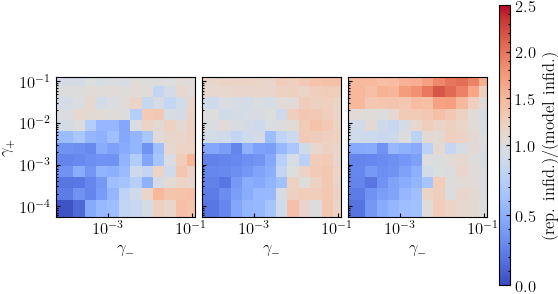

In [122]:
analyse_timesteps = [2,20,200] # average over first 3 timesteps, then timestep 20 and 200

norm = mcolors.TwoSlopeNorm(
    vmin=0.0,
    vcenter=1.0,
    vmax=2.5
)

def plot_single_timestep(i, t, ax, params_grouped):
    if type(t) is tuple: # average over multiple timesteps
        p1 = fidelities_best_mat[:, t[0]] # Error probabilities at time t for model
        p2 = fidelities_mat_stab[:, t[0]] # Error probabilities at time t for stabilizer code

        for tt in t[1:]:
            p1 = p1 + fidelities_best_mat[:, tt]
            p2 = p2 + fidelities_mat_stab[:, tt]

        p1 = 1 - p1 / len(t)
        p2 = 1 - p2 / len(t)

    else:
        p1 = 1 - fidelities_best_mat[:, t] # Error probabilities at time t for model
        p2 = 1 - fidelities_mat_stab[:, t] # Error probabilities at time t for stabilizer code

    gamma_m_values, gamma_p_values, p1_grid = grid_grouped_params(p1, params_grouped, "gammam", "gammap")
    gamma_m_values2, gamma_p_values2, p2_grid = grid_grouped_params(p2, params_grouped, "gammam", "gammap")
    assert np.allclose(gamma_m_values, gamma_m_values2)
    assert np.allclose(gamma_p_values, gamma_p_values2)

    vals = p2_grid / p1_grid
    print(np.min(vals), np.max(vals))
    print(vals)
    im = ax.pcolormesh(
        gamma_m_values,
        gamma_p_values,
        p2_grid / p1_grid,
        cmap='coolwarm',
        norm=norm,
    )
    ax.set_xlabel("$\\gamma_-$")
    if i == 0:
        ax.set_ylabel("$\\gamma_+$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_aspect('equal')

    return im

fig, axs = plt.subplots(1, len(analyse_timesteps), figsize=(6.1811 - 1.2/2.54, 4), sharey=True)
for i, t in enumerate(analyse_timesteps):
    im = plot_single_timestep(i, t, axs[i], params_grouped_best)

plt.subplots_adjust(wspace=0.05, hspace=0, right=0.88)

# colorbar on the right
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="$\\textrm{(rep. infid.)}$/$\\textrm{(model infid.)}$")
fig.savefig(f"{dir_}/comparison_repetition_vs_model.svg")

plt.show()